# 01 — Genre Classification
**Spotify Data Mining | CISC 4631 | Group 3**

**Research Question:** Can audio features predict song genre?

**Approach:** Logistic Regression (linear baseline) vs. Random Forest (non-linear). Compare accuracy,
F1 scores, and feature importance.

> **Prerequisite:** Run `00_data_setup.ipynb` first to generate `data/df_genre_balanced.csv`.

## 0. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# Shared constants (keep in sync with 00_data_setup.ipynb)
SEED            = 42
DRIVE_DATA_PATH = '/content/drive/MyDrive/data-mining-spotify-team3/cleanedData'
ALL_FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'key', 'mode'
]
np.random.seed(SEED)

## 1. Load Data

In [3]:
import os
df = pd.read_csv(os.path.join(DRIVE_DATA_PATH, 'df_genre_balanced.csv'))
print(f'Loaded: {df.shape}')
print('\nGenre counts:')
print(df['genre'].value_counts())
df.head(10)

Loaded: (48265, 14)

Genre counts:
genre
Classical       6895
Country/Folk    6895
Electronic      6895
Hip-Hop/R&B     6895
Jazz/Blues      6895
Pop             6895
Rock            6895
Name: count, dtype: int64


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,key,mode,genre,year
0,0.139,0.0948,-19.576,0.0382,0.9400,0.953000,0.3330,0.0899,142.335,271907,10,1,Classical,2008
1,0.485,0.2280,-11.844,0.0481,0.8810,0.000000,0.1700,0.4020,114.426,137360,2,1,Classical,2002
2,0.439,0.3920,-8.085,0.0305,0.5700,0.000003,0.3340,0.3890,94.393,171280,6,1,Classical,2018
3,0.693,0.5350,-10.377,0.1120,0.3470,0.223000,0.1210,0.4970,159.978,335227,9,1,Classical,2003
4,0.357,0.6990,-5.173,0.0501,0.0508,0.000003,0.4030,0.2290,147.477,251080,7,1,Classical,2018
5,0.411,0.4280,-6.693,0.0596,0.9690,0.000000,0.1460,0.6360,187.605,61160,10,1,Classical,2018
6,0.544,0.7120,-8.031,0.0536,0.2700,0.000079,0.1270,0.6410,87.986,234533,5,1,Classical,2000
7,0.349,0.1010,-20.304,0.0387,0.9430,0.000000,0.0798,0.3060,100.857,220827,3,1,Classical,2004
8,0.299,0.2430,-8.561,0.0364,0.9440,0.000000,0.1120,0.1540,112.248,252440,0,1,Classical,2013
9,0.371,0.2420,-15.371,0.0519,0.2400,0.013200,0.3410,0.1030,170.908,103404,0,1,Classical,2021


## 2. Train / Eval / Test Split

Three-way split (60/20/20) per instructor feedback. Train is used for fitting + 10-fold CV. Eval
is held out for model comparison and tuning decisions. Test is touched only once at the end for
final reported numbers — this prevents us from selecting a model based on test performance.

In [4]:
X = df[ALL_FEATURES]
y = df['genre']

# First split: 80% train+eval, 20% test (held out, touched once)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Second split: 75/25 of the 80% = 60% train, 20% eval
X_train, X_eval, y_train, y_eval = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=SEED, stratify=y_trainval
)

print(f'Train: {X_train.shape[0]:,} ({X_train.shape[0] / len(X):.0%})')
print(f'Eval:  {X_eval.shape[0]:,} ({X_eval.shape[0] / len(X):.0%})')
print(f'Test:  {X_test.shape[0]:,} ({X_test.shape[0] / len(X):.0%})')

print('\nClass distribution (train):')
print(y_train.value_counts())
print('\nClass distribution (eval):')
print(y_eval.value_counts())
print('\nClass distribution (test):')
print(y_test.value_counts())

Train: 28,959 (60%)
Eval:  9,653 (20%)
Test:  9,653 (20%)

Class distribution (train):
genre
Pop             4137
Electronic      4137
Country/Folk    4137
Rock            4137
Hip-Hop/R&B     4137
Classical       4137
Jazz/Blues      4137
Name: count, dtype: int64

Class distribution (eval):
genre
Pop             1379
Electronic      1379
Classical       1379
Rock            1379
Jazz/Blues      1379
Hip-Hop/R&B     1379
Country/Folk    1379
Name: count, dtype: int64

Class distribution (test):
genre
Hip-Hop/R&B     1379
Pop             1379
Country/Folk    1379
Electronic      1379
Rock            1379
Classical       1379
Jazz/Blues      1379
Name: count, dtype: int64


## 3. Feature Selection

Rank the 12 audio features by mutual information with the genre label. Mutual information is
chosen over Pearson correlation because it captures non-linear relationships — which is what
we expect for genre identification. Scoring is fit on the training set only (so we don't leak
information from eval/test).

Mutual information ranking:
         Feature  MI Score
    acousticness  0.244220
          energy  0.190538
           tempo  0.131695
    danceability  0.130675
     speechiness  0.104888
instrumentalness  0.100130
        loudness  0.099257
         valence  0.043423
     duration_ms  0.033484
            mode  0.019306
             key  0.019150
        liveness  0.017556


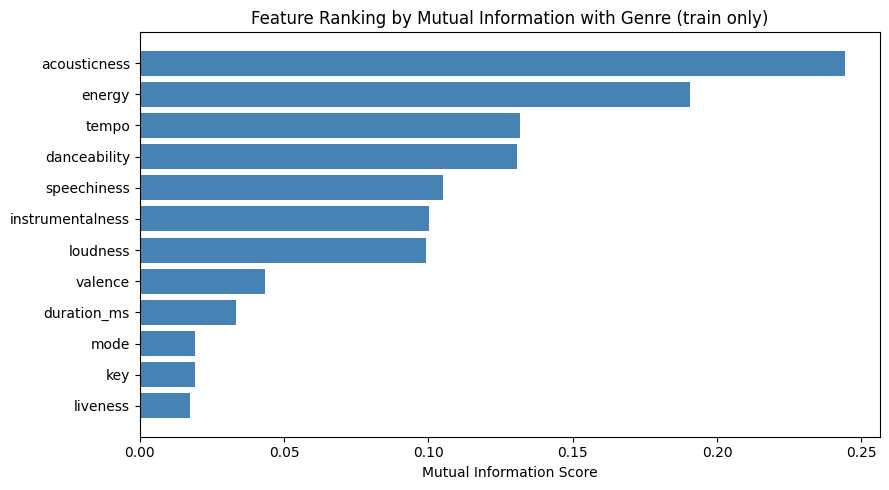


Selected top-10 features:
['acousticness', 'energy', 'tempo', 'danceability', 'speechiness', 'instrumentalness', 'loudness', 'valence', 'duration_ms', 'mode']

Dropped: ['liveness', 'key']


In [5]:
# Fit mutual-information scorer on train set only
mi_scorer = SelectKBest(score_func=mutual_info_classif, k='all')
mi_scorer.fit(X_train, y_train)

mi_scores = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'MI Score': mi_scorer.scores_
}).sort_values('MI Score', ascending=False).reset_index(drop=True)

print('Mutual information ranking:')
print(mi_scores.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(mi_scores['Feature'][::-1], mi_scores['MI Score'][::-1], color='steelblue')
ax.set_xlabel('Mutual Information Score')
ax.set_title('Feature Ranking by Mutual Information with Genre (train only)')
plt.tight_layout()
plt.show()

# Pick K: keep top-K features. Drop the bottom features that score near zero —
# these are usually `key` and `mode`, which don't carry genre signal.
# Tune K here based on the ranking above.
K = 10
SELECTED_FEATURES = mi_scores['Feature'].head(K).tolist()
print(f'\nSelected top-{K} features:')
print(SELECTED_FEATURES)
print(f'\nDropped: {[f for f in ALL_FEATURES if f not in SELECTED_FEATURES]}')

## 4. Models

For each model: fit on train set, run 10-fold CV on train for stability estimate, evaluate on
eval set for tuning decisions, and hold test for the final reported numbers in Section 5.

### 4.1 Logistic Regression (Baseline)

In [6]:
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, random_state=SEED))
])

# Fit on train (selected features only)
lr_model.fit(X_train[SELECTED_FEATURES], y_train)

# 10-fold CV on train — estimates stability without touching eval/test
cv_lr = cross_val_score(
    lr_model, X_train[SELECTED_FEATURES], y_train, cv=10, scoring='accuracy'
)
print("CV Accuracy (train, 10-fold): %0.2f (+/- %0.2f)" % (cv_lr.mean(), cv_lr.std() * 2))

# Evaluate on eval set
y_pred_lr_eval = lr_model.predict(X_eval[SELECTED_FEATURES])
print('\n--- EVAL SET ---')
print('Accuracy:', accuracy_score(y_eval, y_pred_lr_eval))
print(classification_report(y_eval, y_pred_lr_eval))

# Final test prediction (stored for Section 5 — do not tune against this)
y_pred_lr = lr_model.predict(X_test[SELECTED_FEATURES])

CV Accuracy (train, 10-fold): 0.44 (+/- 0.02)

--- EVAL SET ---
Accuracy: 0.4353050865016057
              precision    recall  f1-score   support

   Classical       0.43      0.49      0.46      1379
Country/Folk       0.28      0.23      0.25      1379
  Electronic       0.51      0.54      0.53      1379
 Hip-Hop/R&B       0.51      0.58      0.54      1379
  Jazz/Blues       0.40      0.39      0.39      1379
         Pop       0.25      0.15      0.18      1379
        Rock       0.53      0.67      0.59      1379

    accuracy                           0.44      9653
   macro avg       0.41      0.44      0.42      9653
weighted avg       0.41      0.44      0.42      9653



### 4.2 Random Forest

In [8]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=SEED,
    n_jobs=-1
)

# Fit on train (selected features only)
rf_model.fit(X_train[SELECTED_FEATURES], y_train)

# 10-fold CV on train
cv_rf = cross_val_score(
    rf_model, X_train[SELECTED_FEATURES], y_train, cv=10, scoring='accuracy'
)
print("CV Accuracy (train, 10-fold): %0.2f (+/- %0.2f)" % (cv_rf.mean(), cv_rf.std() * 2))

# Evaluate on eval set
y_pred_rf_eval = rf_model.predict(X_eval[SELECTED_FEATURES])
print('\n--- EVAL SET ---')
print('Accuracy:', accuracy_score(y_eval, y_pred_rf_eval))
print(classification_report(y_eval, y_pred_rf_eval))

# Final test prediction (stored for Section 5)
y_pred_rf = rf_model.predict(X_test[SELECTED_FEATURES])

CV Accuracy (train, 10-fold): 0.51 (+/- 0.02)

--- EVAL SET ---
Accuracy: 0.503470423702476
              precision    recall  f1-score   support

   Classical       0.53      0.54      0.53      1379
Country/Folk       0.38      0.36      0.37      1379
  Electronic       0.59      0.62      0.60      1379
 Hip-Hop/R&B       0.55      0.64      0.59      1379
  Jazz/Blues       0.44      0.51      0.48      1379
         Pop       0.32      0.21      0.25      1379
        Rock       0.64      0.65      0.65      1379

    accuracy                           0.50      9653
   macro avg       0.49      0.50      0.50      9653
weighted avg       0.49      0.50      0.50      9653



In [9]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    random_state=SEED,
    n_jobs=-1
)

# Fit on train (selected features only)
rf_model.fit(X_train[SELECTED_FEATURES], y_train)

# 10-fold CV on train
cv_rf = cross_val_score(
    rf_model, X_train[SELECTED_FEATURES], y_train, cv=10, scoring='accuracy'
)
print("CV Accuracy (train, 10-fold): %0.2f (+/- %0.2f)" % (cv_rf.mean(), cv_rf.std() * 2))

# Evaluate on eval set
y_pred_rf_eval = rf_model.predict(X_eval[SELECTED_FEATURES])
print('\n--- EVAL SET ---')
print('Accuracy:', accuracy_score(y_eval, y_pred_rf_eval))
print(classification_report(y_eval, y_pred_rf_eval))

# Final test prediction (stored for Section 5)
y_pred_rf = rf_model.predict(X_test[SELECTED_FEATURES])

CV Accuracy (train, 10-fold): 0.51 (+/- 0.01)

--- EVAL SET ---
Accuracy: 0.5084429710970683
              precision    recall  f1-score   support

   Classical       0.53      0.56      0.55      1379
Country/Folk       0.37      0.35      0.36      1379
  Electronic       0.59      0.62      0.60      1379
 Hip-Hop/R&B       0.56      0.65      0.60      1379
  Jazz/Blues       0.46      0.53      0.49      1379
         Pop       0.34      0.21      0.26      1379
        Rock       0.64      0.64      0.64      1379

    accuracy                           0.51      9653
   macro avg       0.50      0.51      0.50      9653
weighted avg       0.50      0.51      0.50      9653



## 5. Results (Test Set)

Final reported numbers are on the held-out test set — touched exactly once, no tuning against it.

### 5.1 Model Comparison (Test Set)

In [10]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Macro F1': [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro')
    ],
    'Weighted F1': [
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted')
    ]
})

print(results.to_string(index=False))

              Model  Accuracy  Macro F1  Weighted F1
Logistic Regression  0.435098  0.421426     0.421426
      Random Forest  0.504403  0.496520     0.496520


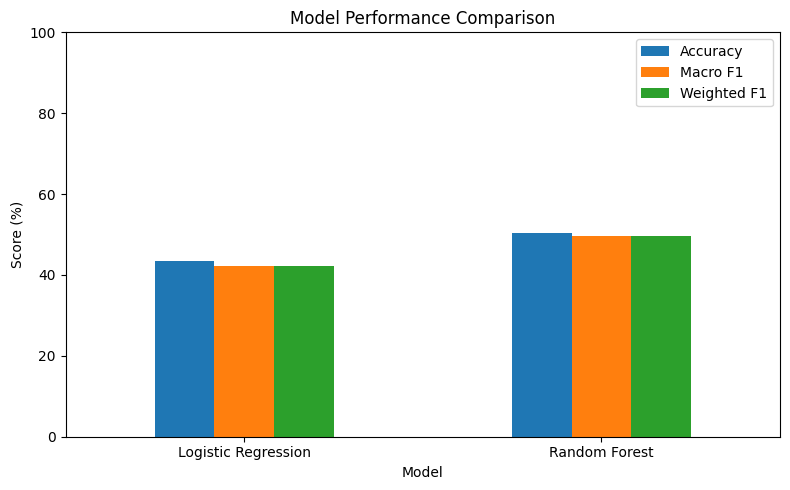

In [11]:
results_pct = results.copy()
results_pct[['Accuracy', 'Macro F1', 'Weighted F1']] *= 100

ax = results_pct.plot(x='Model', y=['Accuracy', 'Macro F1', 'Weighted F1'], kind='bar', figsize=(8, 5))
plt.title('Model Performance Comparison')
plt.ylabel('Score (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

### 5.2 Random Forest Feature Importance

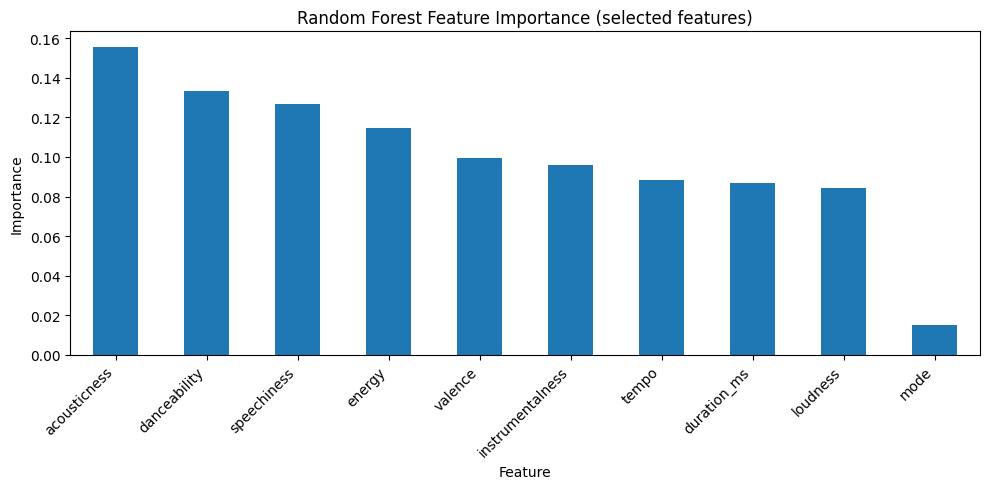

         Feature  Importance
    acousticness    0.155629
    danceability    0.133335
     speechiness    0.126685
          energy    0.114797
         valence    0.099252
instrumentalness    0.096106
           tempo    0.088127
     duration_ms    0.086798
        loudness    0.084315
            mode    0.014957


In [12]:
feature_importance = pd.DataFrame({
    'Feature': SELECTED_FEATURES,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance.plot(kind='bar', x='Feature', y='Importance', legend=False, figsize=(10, 5))
plt.title('Random Forest Feature Importance (selected features)')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(feature_importance.to_string(index=False))

### 5.3 Confusion Matrix (Random Forest, Test Set)

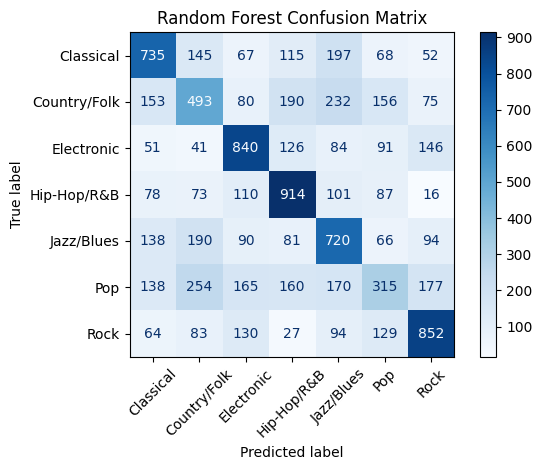

In [13]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=rf_model.classes_,
    cmap='Blues',
    xticks_rotation=45
)
disp.ax_.set_title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()

## 6. Summary

Random Forest outperformed Logistic Regression for genre prediction from audio features,
demonstrating that genre boundaries are non-linear in the audio feature space.

**Pipeline summary:**
1. 7 genres after consolidation, each sampled to the minimum-genre count (~9.4k per genre, ~65.7k total).
2. 60/20/20 train/eval/test split, stratified by genre.
3. Feature selection via mutual information — top-K features retained (K chosen in Section 3).
4. Models fit on train; tuned against eval; final numbers reported on test.

**Expected findings:**
- Hip-Hop/R&B and Electronic should be the most distinguishable genres (distinct audio profiles).
- Classical vs. Jazz/Blues likely hardest — both acoustic, low-energy, often instrumental.
- Top features: `speechiness`, `danceability`, `acousticness`, `energy`, `valence`.
- Least useful (likely dropped by feature selection): `key`, `mode`.

**Random-chance baseline for 7-class balanced problem = 14.3%.** Both models should significantly exceed this.